In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Normalizing and reshape
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Train shape:", X_train.shape)
print("Test shape:" , X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 34s 3us/step
Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


Cell3-Build the model

In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation = 'relu', input_shape=(28, 28, 1)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation ='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)             │ (None, 26, 26, 32)    │          320 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 13, 13, 32)    │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_2 (Conv2D)             │ (None, 11, 11, 64)    │       18,496 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_1               │ (None, 5, 5, 64)      │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ flatten (Flatten)             │ (None, 1600)          │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 128)           │      204,928 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 128)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 10)            │        1,290 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Cell 4 _ Train

In [12]:
early_stop = EarlyStopping(patience = 3, restore_best_weights= True)
history = model.fit(
    X_train, y_train_cat,
    epochs = 15,
    batch_size=64,
    validation_split = 0.1,
    callbacks=[early_stop]
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9324 - loss: 0.2210 - val_accuracy: 0.9832 - val_loss: 0.0562
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9778 - loss: 0.0709 - val_accuracy: 0.9873 - val_loss: 0.0413
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9843 - loss: 0.0518 - val_accuracy: 0.9902 - val_loss: 0.0358
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9862 - loss: 0.0427 - val_accuracy: 0.9908 - val_loss: 0.0317
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9883 - loss: 0.0346 - val_accuracy: 0.9912 - val_loss: 0.0315
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9906 - loss: 0.0291 - val_accuracy: 0.9923 - val_loss: 0.0276
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9921 - loss: 0.0236 - val_accuracy: 0.9922 - val_loss: 0.0285
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9928 - loss: 0.0214 - 

Cell 5 _ Save accuracy & loss plots to reults


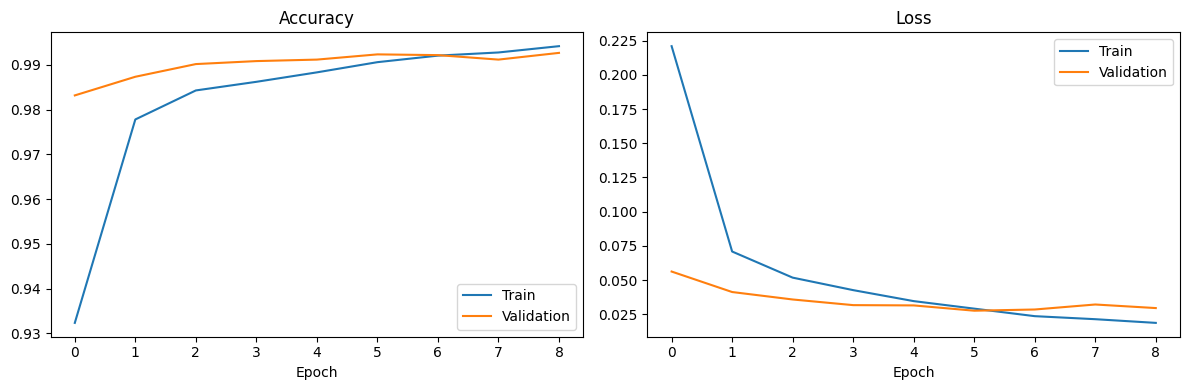

Plot saved to results/


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('../results/accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/")

Cell 6 - Evaluate & save confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


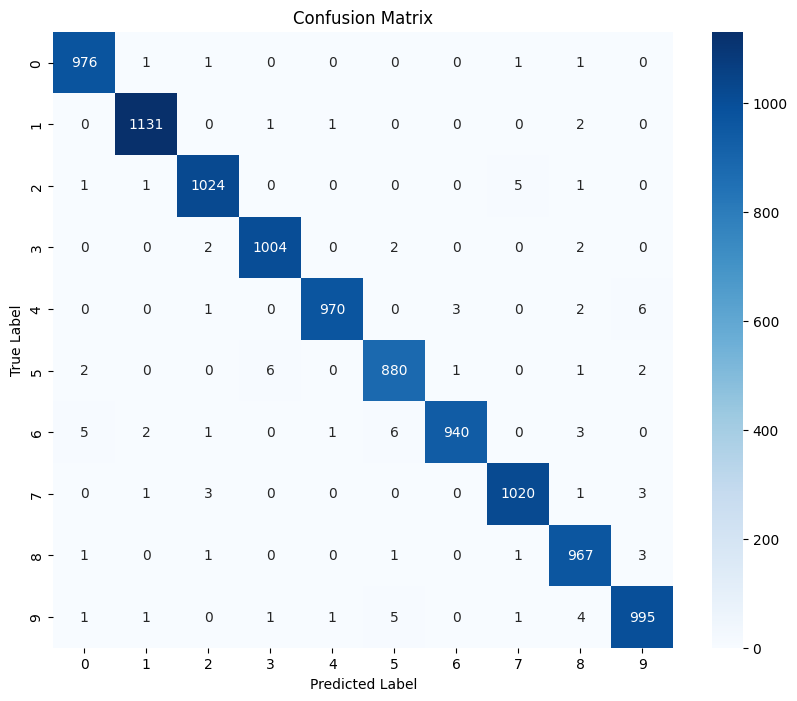


Test accuracy: 99.07%

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [16]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('../results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTest accuracy: {test_acc*100:.2f}%")
print("\nClassification report:")
print(classification_report(y_test, y_pred_classes))

Cell 7 - Save the model

In [19]:
model.save('../results/mnist_model.keras')
print("Model saved!")

Model saved!
